In [2]:
import numpy as np
from numba import njit

import plotly.graph_objects as go
import matplotlib.pyplot as plt
import fastplotlib as fpl

from scipy import sparse
from scipy.sparse.linalg import eigs

from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

import warnings

import optuna
import optuna.visualization as vis
from optuna.exceptions import ExperimentalWarning
from optuna.importance import PedAnovaImportanceEvaluator

In [3]:
steps = 20000

tau_steps = 1

transient_steps_henon = int(steps * 0.1)
transient_steps_reservoir = int(steps * 0.1)

total_steps = steps + transient_steps_henon + transient_steps_reservoir + tau_steps
total_steps_after_henon = steps + transient_steps_reservoir + tau_steps
total_steps_after_reservoir = steps + tau_steps

test_size = 0.2
test_steps = int(steps * test_size)

t = np.arange(0, total_steps)

# Init

In [4]:
henon_dataset = np.zeros((total_steps, 2))

rng = np.random.default_rng(42)
henon_dataset[0] = rng.random(2)

a = 1.4
b = .3

In [5]:
@njit
def henon_numba(steps, a=1.4, b=0.3, x0=0.0, y0=0.0):
    X = np.zeros(steps)
    Y = np.zeros(steps)
    X[0] = x0
    Y[0] = y0

    for i in range(1, steps):
        X[i] = 1 - a * X[i - 1] ** 2 + Y[i - 1]
        Y[i] = b * X[i - 1]

    return X, Y

In [6]:
henon_data_x, henon_data_y = henon_numba(total_steps)

henon_dataset = np.column_stack((henon_data_x, henon_data_y))
henon_dataset = henon_dataset[transient_steps_henon:]

In [7]:
henon_scaler = StandardScaler()
henon_scaled = henon_scaler.fit_transform(henon_dataset)

In [8]:
def henon_plot(data):
    fig = go.Figure(
        data=go.Scatter(
            x=data[:, 0],
            y=data[:, 1],
            mode="markers",
            marker=dict(color="white", size=1)
        )
    )
    
    fig.update_layout(
        plot_bgcolor="black",
        paper_bgcolor="black",
        font=dict(color="white"),
        
        xaxis=dict(
            showgrid=False, 
            zeroline=False, 
            linecolor="white",
            ticks="outside",
            tickcolor="white"
        ),
        yaxis=dict(
            showgrid=False,
            zeroline=False,
            linecolor="white",
            ticks="outside",
            tickcolor="white"
        )
    )
    
    return fig

In [9]:
fig = henon_plot(henon_scaled)
fig.show()

In [10]:
def r_2_plot(actual, predicted):
    r_2 = r2_score(actual, predicted)

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=actual,
            y=predicted,
            mode="markers",
            name="Data Points",
            marker=dict(color="rgba(50, 50, 200, 0.5)", size=5),
        )
    )

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    fig.add_trace(
        go.Scatter(
            x=[min_val, max_val],
            y=[min_val, max_val],
            mode="lines",
            name="Ideal Prediction",
            line=dict(color="firebrick", dash="dash"),
        )
    )

    fig.update_layout(
        title=f"Actual vs. Predicted (R²: {r_2:.4f})",
        xaxis_title="Actual Values",
        yaxis_title="Predicted Values",
        showlegend=True,
    )
    return fig

# Henon Map Plots

## Graph Lots of Points and Why Fractal

It's a fractal cause when get closer to a specific points it kinda look similar at all these scales. Or basically as we just get closer the edges start to look like they repeat themselves.

In [16]:
henon_data_x, henon_data_y = henon_numba(1_000_000)
data = np.column_stack([henon_data_x, henon_data_y])

fig = fpl.Figure(canvas="glfw")

scatter = fig[0, 0].add_scatter(data, sizes=2, colors="white", alpha=.3)

fig.show()

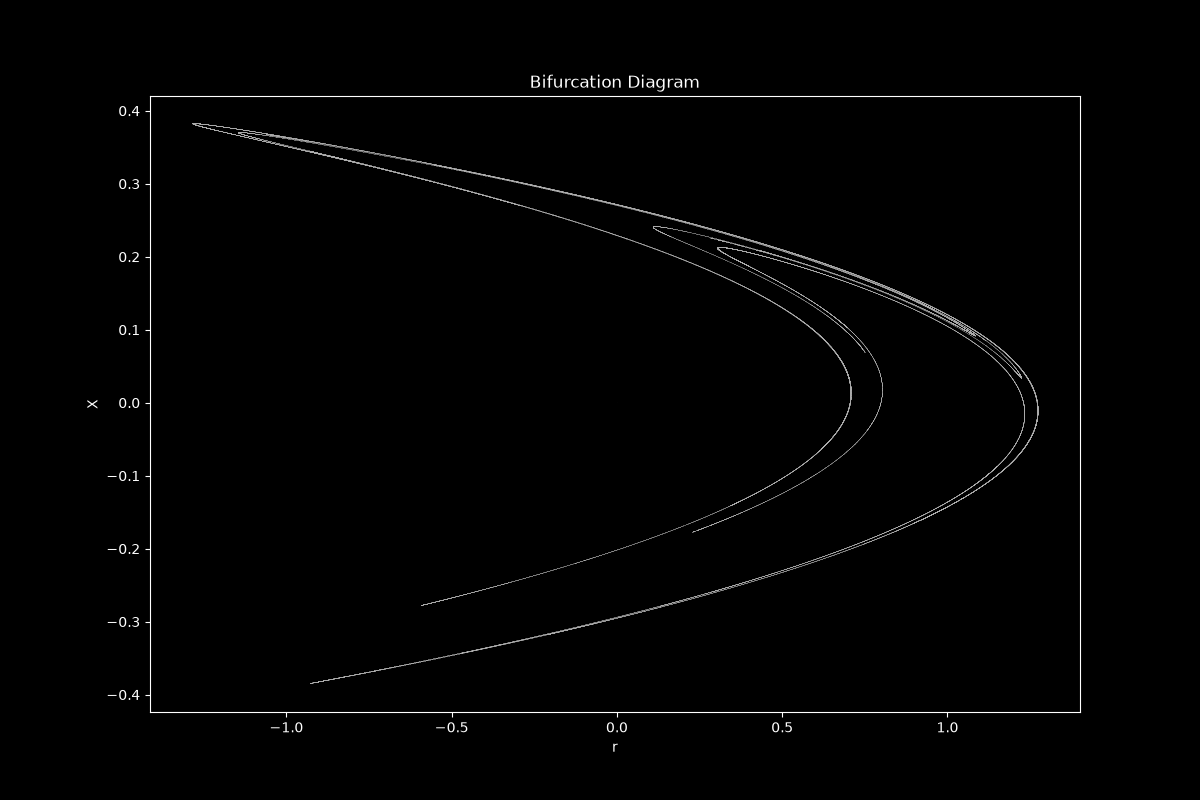

In [12]:
%matplotlib widget
henon_data_x, henon_data_y = henon_numba(1_000_000)

plt.style.use("dark_background")
plt.figure(figsize=(12, 8))

plt.plot(
    henon_data_x, henon_data_y, ",", color="white", alpha=0.013
)

plt.title("Bifurcation Diagram")
plt.xlabel("r")
plt.ylabel("X")
plt.show()

## Boundaries of Basin Attraction

# Henon Open

## Default Vals

In [11]:
in_size = 2
out_size = 2
res_size = 300
sparsity = 0.1
spec_rad = 1.0
alpha = .7
input_scaling = 2

In [12]:
rng = np.random.default_rng(42)

bias = rng.uniform(-input_scaling, input_scaling, res_size)

W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))

W_sparse = sparse.random(
    res_size,
    res_size,
    density=sparsity,
    format="csr",
    data_rvs=lambda n: rng.uniform(-1.0, 1.0, n),
    rng=rng,
)
v0 = rng.normal(size=W_sparse.shape[0])
eigenvalues, _ = eigs(W_sparse, k=1, which="LM", v0=v0)
largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))

W_res = W_sparse * (spec_rad / largest_eigenvalue)

In [13]:
X = np.zeros((total_steps_after_henon, res_size))
X[0] = np.tanh(0)

for i in range(1, total_steps_after_henon):
    u = henon_scaled[i - 1]
    prev_state = X[i - 1]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X[i] = (1 - alpha) * prev_state + alpha * new_state

In [ ]:
X_data = X[transient_steps_reservoir:- tau_steps]
Y_data = henon_scaled[
    transient_steps_reservoir+tau_steps:
]

X_train, X_test = (
    X_data[:-test_steps],
    X_data[-test_steps:],
)
Y_train, Y_test_unscaled = (
    Y_data[:-test_steps],
    Y_data[-test_steps:],
)

model = RidgeCV()
model.fit(X_train, Y_train)
Y_pred_scaled = model.predict(X_test)

Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)
Y_test = henon_scaler.inverse_transform(Y_test_unscaled)

In [15]:
r_2 = r2_score(Y_test, Y_pred)
mse = root_mean_squared_error(Y_test, Y_pred)

r_2, mse

(0.9997841637944755, 0.007770880603052555)

Lowkey kinda confused I was trying different values and the input scaled to 2 and the alpha being .7 which places less importance on the reservoir does way better.

### Plots

In [17]:
henon_plot(henon_dataset[-Y_pred.shape[0] :]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()

## Bayesian

In [210]:
def henon_closed(in_size, out_size, res_size, sparsity, spec_rad, alpha, input_scaling, ridge_alpha, tau_steps):
    rng = np.random.default_rng(42)
    bias = rng.uniform(-input_scaling, input_scaling, res_size)
    W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))
    W_res = rng.uniform(-1.0, 1.0, (res_size, res_size)) # Scaled by spectral radius anyways
    # Between 0 and 1 and true if above sparsity value
    mask = rng.random((res_size, res_size)) > sparsity
    W_res[mask] = 0.0
    try:
        v0 = rng.normal(size=W_res.shape[0])
        eigenvalues, _ = eigs(W_res, k=1, which="LM", v0=v0)
    except Exception as e:
        raise optuna.exceptions.TrialPruned()
    largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))
    W_res = W_res * (spec_rad / largest_eigenvalue)

    X = np.zeros((total_steps_after_henon, res_size))
    X[0] = np.tanh(0)
    for i in range(1, total_steps_after_henon):
        u = henon_scaled[i - 1]
        prev_state = X[i - 1]
        new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
        X[i] = (1 - alpha) * prev_state + alpha * new_state

    X_data = X[transient_steps_reservoir:- tau_steps]
    Y_data = henon_scaled[
        transient_steps_reservoir+tau_steps:
    ]
    X_train, X_test = (
        X_data[:-test_steps],
        X_data[-test_steps:],
    )
    Y_train, Y_test_unscaled = (
        Y_data[:-test_steps],
        Y_data[-test_steps:],
    )
    model = Ridge(alpha=ridge_alpha)
    model.fit(X_train, Y_train)
    Y_pred_scaled = model.predict(X_test)

    Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)
    Y_test = henon_scaler.inverse_transform(Y_test_unscaled)

    r_2 = r2_score(Y_test, Y_pred)
    mse = root_mean_squared_error(Y_test, Y_pred)

    return r_2, mse, Y_test, Y_pred

In [ ]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=trial.suggest_int("res_size", 10, 2000),
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-13, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

In [79]:
best_trials = study.best_trials

print("Pareto Front trials:")
for trial in best_trials:
    print(f"Trial {trial.number}: R2={trial.values[0]}, MSE={trial.values[1]}")
    print(f"Params: {trial.params}")

Pareto Front trials:
Trial 42: R2=0.999998914715901, MSE=0.0005451841722179898
Params: {'res_size': 1383, 'sparsity': 0.34243920415221035, 'spec_rad': 1.015769360478675, 'alpha': 0.6139139761030279, 'input_scaling': 1.5982616998894263, 'ridge_alpha': 1.4930440199352496e-07}


In [80]:
params = study.best_trials[0].params
r_2, mse, Y_test, Y_pred = henon_closed(
    in_size=2,
    out_size=2,
    res_size=params["res_size"],
    sparsity=params["sparsity"],
    spec_rad=params["spec_rad"],
    alpha=params["alpha"],
    input_scaling=params["input_scaling"],
    ridge_alpha=params["ridge_alpha"],
    tau_steps=1,
)
r_2, mse

{'res_size': 1383, 'sparsity': 0.34243920415221035, 'spec_rad': 1.015769360478675, 'alpha': 0.6139139761030279, 'input_scaling': 1.5982616998894263, 'ridge_alpha': 1.4930440199352496e-07}


(0.999998914715901, 0.0005451841722179898)

### Plots

In [81]:
henon_plot(henon_dataset[-Y_pred.shape[0] :]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()
vis.plot_pareto_front(study, target_names=["R2 Score", "MSE"]).show()

In [82]:
fig_slice_r2 = vis.plot_slice(
    study,
    params=[
        "res_size",
        "sparsity",
        "spec_rad",
        "alpha",
        "input_scaling",
        "ridge_alpha",
    ],
    target=lambda t: t.values[0],
    target_name="R2 Score",
)
fig_slice_r2.show()

fig_slice_mse = vis.plot_slice(
    study,
    params=[
        "res_size",
        "sparsity",
        "spec_rad",
        "alpha",
        "input_scaling",
        "ridge_alpha",
    ],
    target=lambda t: t.values[1],
    target_name="MSE",
)
fig_slice_mse.show()

In [83]:
fig_importance_r_2 = vis.plot_param_importances(
    study, target=lambda t: t.values[0], target_name="R2 Score"
)
fig_importance_r_2.show()
fig_importance_mse = vis.plot_param_importances(
    study, target=lambda t: t.values[1], target_name="MSE"
)
fig_importance_mse.show()

In [84]:
# Default fANOVA: is what parameters cause the biggest changes in R² across the entire search space (including massive drops into bad/unstable configurations)
# PED-ANOVA: What parameters are critical to push a model configuration into the top 10% of all results?
# AI ahhh explanation but since I increase ridge values so much they became more important than they should be
warnings.filterwarnings("ignore", category=ExperimentalWarning)
top_5_percent_evaluator = PedAnovaImportanceEvaluator(target_quantile=0.05)

fig_importance_r_2 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0] * -1.0,
    target_name="R2 Score",
    evaluator=top_5_percent_evaluator,
)
fig_importance_r_2.show()

fig_importance_mse = vis.plot_param_importances(
    study,
    target=lambda t: t.values[1],
    target_name="MSE",
    evaluator=top_5_percent_evaluator,
)
fig_importance_mse.show()

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/215902989.py:7: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_r_2 = vis.plot_param_importances(


/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/215902989.py:15: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_mse = vis.plot_param_importances(


### Test Without Sparsity for Speed

In [85]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=150,
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-13, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [86]:
best_trials = study.best_trials

print("Pareto Front trials:")
for trial in best_trials:
    print(f"Trial {trial.number}: R2={trial.values[0]}, MSE={trial.values[1]}")
    print(f"Params: {trial.params}")

Pareto Front trials:
Trial 9: R2=0.9999026823889172, MSE=0.005166029413180507
Params: {'sparsity': 0.2608201491123842, 'spec_rad': 0.5844408037621838, 'alpha': 0.7755672176095767, 'input_scaling': 1.6771437373523959, 'ridge_alpha': 7.692129890322106e-06}


In [87]:
params = study.best_trials[0].params
r_2, mse, Y_test, Y_pred = henon_closed(
    in_size=2,
    out_size=2,
    res_size=150,
    sparsity=params["sparsity"],
    spec_rad=params["spec_rad"],
    alpha=params["alpha"],
    input_scaling=params["input_scaling"],
    ridge_alpha=params["ridge_alpha"],
    tau_steps=1,
)
r_2, mse

(0.9999026823889172, 0.005166029413180507)

#### Plots

In [88]:
henon_plot(henon_dataset[-Y_pred.shape[0] :]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()
vis.plot_pareto_front(study, target_names=["R2 Score", "MSE"]).show()

In [89]:
fig_slice_r2 = vis.plot_slice(
    study,
    params=[
        "sparsity",
        "spec_rad",
        "alpha",
        "input_scaling",
        "ridge_alpha",
    ],
    target=lambda t: t.values[0],
    target_name="R2 Score",
)
fig_slice_r2.show()

fig_slice_mse = vis.plot_slice(
    study,
    params=[
        "sparsity",
        "spec_rad",
        "alpha",
        "input_scaling",
        "ridge_alpha",
    ],
    target=lambda t: t.values[1],
    target_name="MSE",
)
fig_slice_mse.show()

In [90]:
warnings.filterwarnings("ignore", category=ExperimentalWarning)
top_5_percent_evaluator = PedAnovaImportanceEvaluator(target_quantile=0.05)

fig_importance_r_2 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0] * -1.0,
    target_name="R2 Score",
    evaluator=top_5_percent_evaluator,
)
fig_importance_r_2.show()

fig_importance_mse = vis.plot_param_importances(
    study,
    target=lambda t: t.values[1],
    target_name="MSE",
    evaluator=top_5_percent_evaluator,
)
fig_importance_mse.show()

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/3138544416.py:4: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_r_2 = vis.plot_param_importances(


/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/3138544416.py:12: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_mse = vis.plot_param_importances(


### Speed Up

In [220]:
@njit
def compute_states(steps, henon_inputs, res_size, W_in, W_res, bias, alpha):
    X_data = np.zeros((steps, res_size), dtype=np.float32)
    state = np.zeros(res_size, dtype=np.float32)
    X_data[0] = np.tanh(np.float32(0.0))
    input_projections = henon_inputs @ W_in.T

    for i in range(1, steps):
        state = (np.float32(1.0) - alpha) * state + alpha * np.tanh(
            input_projections[i - 1] + W_res @ state + bias
        )
        X_data[i] = state
    return X_data

In [221]:
def henon_closed_fast(
    in_size,
    out_size,
    res_size,
    sparsity,
    spec_rad,
    alpha,
    input_scaling,
    ridge_alpha,
    tau_steps,
):
    rng = np.random.default_rng(42)
    bias = rng.uniform(-input_scaling, input_scaling, res_size)
    W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))
    W_res = rng.uniform(-1.0, 1.0, (res_size, res_size))
    mask = rng.random((res_size, res_size)) > sparsity
    W_res[mask] = 0.0
    try:
        eigenvalues = np.linalg.eigvals(W_res)
    except Exception as e:
        raise optuna.exceptions.TrialPruned()
    largest_eigenvalue = np.round(np.max(np.abs(eigenvalues)), decimals=12)
    W_res = W_res * (spec_rad / largest_eigenvalue)

    X_data = compute_states(
        total_steps_after_henon,
        henon_scaled.astype(np.float32),
        res_size,
        W_in.astype(np.float32),
        W_res.astype(np.float32),
        bias.astype(np.float32),
        np.float32(alpha),
    )

    X_data = X_data[transient_steps_reservoir:-tau_steps]
    Y_data = henon_scaled[transient_steps_reservoir + tau_steps :]
    X_train, X_test = (
        X_data[:-test_steps],
        X_data[-test_steps:],
    )
    Y_train, Y_test_unscaled = (
        Y_data[:-test_steps],
        Y_data[-test_steps:],
    )
    model = Ridge(alpha=ridge_alpha, solver="svd")
    model.fit(X_train, Y_train)
    Y_pred_scaled = model.predict(X_test)

    Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)
    Y_test = henon_scaler.inverse_transform(Y_test_unscaled)

    r_2 = r2_score(Y_test, Y_pred)
    mse = root_mean_squared_error(Y_test, Y_pred)

    return r_2, mse, Y_test, Y_pred

In [230]:
in_size = 2
out_size = 2
res_size = 1500
sparsity = 0.5
spec_rad = 0.85
alpha = 0.6
input_scaling = 2
ridge_alpha = 1e-10

r_2, mse, Y_test, Y_pred = henon_closed_fast(
    in_size=in_size,
    out_size=out_size,
    res_size=res_size,
    sparsity=sparsity,
    spec_rad=spec_rad,
    alpha=alpha,
    input_scaling=input_scaling,
    ridge_alpha=ridge_alpha,
    tau_steps=1,
)
r_2, mse

(0.9999999022145613, 0.00016377123828389622)

In [223]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed_fast(
        in_size=2,
        out_size=2,
        res_size=200,
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-11, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [224]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=200,
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-11, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [225]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed_fast(
        in_size=2,
        out_size=2,
        res_size=trial.suggest_int("res_size", 10, 2000),
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-11, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [226]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)
    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=trial.suggest_int("res_size", 10, 2000),
        sparsity=trial.suggest_float("sparsity", 0.01, 0.8),
        spec_rad=trial.suggest_float("spec_rad", 0.5, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-11, 10.0, log=True),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

2:30 vs 1:07

# Henon Close

## Default Vals

In [180]:
in_size = 2
out_size = 2
res_size = 600
sparsity = 0.5
spec_rad = 0.85
alpha = 0.6
input_scaling = 2
ridge_alpha = 1e-10

In [181]:
rng = np.random.default_rng(42)

bias = rng.uniform(-input_scaling, input_scaling, res_size)

W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))

W_res = rng.uniform(-1.0, 1.0, (res_size, res_size))
mask = rng.random((res_size, res_size)) > sparsity
W_res[mask] = 0.0

v0 = rng.normal(size=W_res.shape[0])
eigenvalues, _ = eigs(W_res, k=1, which="LM", v0=v0)
largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))

W_res = W_res * (spec_rad / largest_eigenvalue)

In [182]:
X_train = np.zeros(
    (steps + transient_steps_reservoir - test_steps, res_size)
)  # 18,000 then subtract 2,000 for transient so 16,000
henon_train = henon_scaled[: -test_steps - tau_steps] # Just first 18,000 vals

X_train[0] = np.tanh(0)
for i in range(1, steps + transient_steps_reservoir - test_steps):
    u = henon_train[i - 1]
    prev_state = X_train[i - 1]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_train[i] = (1 - alpha) * prev_state + alpha * new_state

X_train = X_train[transient_steps_reservoir:]  # We only use 16000
Y_train = henon_scaled[transient_steps_reservoir + tau_steps : -test_steps]


# We have 22,001 values
# Them we remove 4,000 for the testing and later we'll remove 2,000 for the transient state
# Now we have 18,001 currently
# We use the same X and U values to get next value
# Then at the end we remove the last 2,000 for the testing
# So X is then 16,001 but remove 1 for tau so we have 16,000
# Then Y is 16,000 removed for tau but the last step is 16,001 array index in Henon
# Also remember when I say array index I mean the actual step is 16,000 if 0 is a step and the rest is at 15999

In [183]:
model = Ridge(alpha=ridge_alpha)
model.fit(X_train, Y_train);

In [184]:
X_pred = np.zeros((test_steps, res_size))  # 4000 we don't use last item
henon_scaled_test = henon_scaled[
    -test_steps - tau_steps : -tau_steps
]  # We take last 4001 then remove 1 for tau since we don't use it like for X
Y_pred_scaled = np.zeros((test_steps, out_size))  # Starts at 16001 of Henon
Y_test = henon_dataset[-test_steps:]  # Starts at 16001 of Henon
# Y_test = henon_scaled[-test_steps:]
# Basically for an index i we get current reservoir X and current input U(Henon) and future in i+1 of Y


u = Y_train[-2]  # Second to last - Henon[15999] - Y[15998]
prev_state = X_train[-1] # Last - X[15999]
new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
X_pred[0] = (1 - alpha) * prev_state + alpha * new_state  # 16000
Y_pred_scaled[0] = model.predict(
    X_pred[0].reshape(1, -1)
)  # Use X[1600] to predict H[16001] or Y[16000]

u = Y_train[-1]  # Second to last - Henon[1600] - Y[15999]
prev_state = X_pred[0]  # Last - X[16000]
new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
X_pred[1] = (1 - alpha) * prev_state + alpha * new_state  # 16000
Y_pred_scaled[1] = model.predict(
    X_pred[1].reshape(1, -1)
)  # Use X[1601] to predict H[16002] or Y[16001]

for i in range(2, test_steps):
    u = Y_pred_scaled[i - 2]  # Y[16000] - Henon[16001]
    prev_state = X_pred[i - 1] # X[16001]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[i] = (1 - alpha) * prev_state + alpha * new_state # X[16002]
    Y_pred_scaled[i] = model.predict(
        X_pred[i].reshape(1, -1)
    )  # Use X[16002] to predict H[16003] or Y[16002]

Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)

In [185]:
r_2 = r2_score(Y_test, Y_pred)
mse = root_mean_squared_error(Y_test, Y_pred)

r_2, mse

(-2124.3875730803425, 24.37252517606891)

### Plots

In [98]:
henon_plot(henon_dataset[-Y_pred.shape[0]:]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()

## Default Vals with noise

In [174]:
in_size = 2
out_size = 2
res_size = 600
sparsity = 0.5
spec_rad = 0.85
alpha = 0.6
input_scaling = 2
ridge_alpha = 1e-10
noise = 0.1

In [175]:
rng = np.random.default_rng(42)

bias = rng.uniform(-input_scaling, input_scaling, res_size)

W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))

W_res = rng.uniform(-1.0, 1.0, (res_size, res_size))
mask = rng.random((res_size, res_size)) > sparsity
W_res[mask] = 0.0

v0 = rng.normal(size=W_res.shape[0])
eigenvalues, _ = eigs(W_res, k=1, which="LM", v0=v0)
largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))

W_res = W_res * (spec_rad / largest_eigenvalue)

In [176]:
rng = np.random.default_rng(42)

X_train = np.zeros((steps + transient_steps_reservoir - test_steps, res_size))
henon_train = henon_scaled[: -test_steps - tau_steps]

X_train[0] = np.tanh(0)
for i in range(1, steps + transient_steps_reservoir - test_steps):
    u = henon_train[i - 1]
    u_noisy = u + rng.normal(0, noise, size=u.shape)
    prev_state = X_train[i - 1]
    new_state = np.tanh(W_in @ u_noisy + W_res @ prev_state + bias)
    X_train[i] = (1 - alpha) * prev_state + alpha * new_state

X_train = X_train[transient_steps_reservoir:]
Y_train = henon_scaled[transient_steps_reservoir + tau_steps : -test_steps]

In [177]:
model = Ridge(alpha=ridge_alpha)
model.fit(X_train, Y_train);

In [178]:
X_pred = np.zeros((test_steps, res_size))
henon_scaled_test = henon_scaled[-test_steps - tau_steps : -tau_steps]
Y_pred_scaled = np.zeros((test_steps, out_size))
Y_test = henon_dataset[-test_steps:]

u = Y_train[-2]
prev_state = X_train[-1]
new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
X_pred[0] = (1 - alpha) * prev_state + alpha * new_state
Y_pred_scaled[0] = model.predict(X_pred[0].reshape(1, -1))

u = Y_train[-1]
prev_state = X_pred[0]
new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
X_pred[1] = (1 - alpha) * prev_state + alpha * new_state
Y_pred_scaled[1] = model.predict(X_pred[1].reshape(1, -1))

for i in range(2, test_steps):
    u = Y_pred_scaled[i - 2]
    prev_state = X_pred[i - 1]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[i] = (1 - alpha) * prev_state + alpha * new_state
    Y_pred_scaled[i] = model.predict(X_pred[i].reshape(1, -1))

Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)

In [179]:
r_2 = r2_score(Y_test, Y_pred)
mse = root_mean_squared_error(Y_test, Y_pred)

r_2, mse

(-84.29287038394162, 3.9661665737602627)

### Plots

In [139]:
henon_plot(henon_dataset[-Y_pred.shape[0]:]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()

## Bayesian

In [315]:
@njit(fastmath=True)
def compute_states(steps, henon_inputs, res_size, W_in, W_res, bias, alpha, noise):
    X_data = np.zeros((steps, res_size), dtype=np.float32)
    state = np.zeros(res_size, dtype=np.float32)
    X_data[0] = np.tanh(np.float32(0.0))
    input_projections = (henon_inputs + noise) @ W_in.T

    for i in range(1, steps):
        state = (np.float32(1.0) - alpha) * state + alpha * np.tanh(
            input_projections[i - 1] + W_res @ state + bias
        )
        X_data[i] = state
    return X_data

In [316]:
@njit(fastmath=True)
def compute_closed_states(
    steps, Y_pred_scaled, X_pred, W_in, W_res, bias, alpha, W_out, res_size
):
    ONE_MINUS_ALPHA = np.float32(1.0) - alpha

    for i in range(2, steps):
        u = Y_pred_scaled[i - 2]
        prev_state = X_pred[i - 1, :res_size]
        new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
        X_pred[i, :res_size] = ONE_MINUS_ALPHA * prev_state + alpha * new_state
        Y_pred_scaled[i] = W_out @ X_pred[i]
    return Y_pred_scaled

In [ ]:
def henon_closed(
    in_size,
    out_size,
    res_size,
    sparsity,
    spec_rad,
    alpha,
    input_scaling,
    ridge_alpha,
    noise,
    tau_steps,
):
    rng = np.random.default_rng(42)
    bias = rng.uniform(-input_scaling, input_scaling, res_size)
    W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))
    W_res = rng.uniform(-1.0, 1.0, (res_size, res_size))
    mask = rng.random((res_size, res_size)) > sparsity
    W_res[mask] = 0.0
    try:
        v0 = rng.normal(size=W_res.shape[0])
        eigenvalues, _ = eigs(W_res, k=1, which="LM", v0=v0)
    except Exception as e:
        raise optuna.exceptions.TrialPruned()
    largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))
    W_res = W_res * (spec_rad / largest_eigenvalue)

    X_train = compute_states(
        steps + transient_steps_reservoir - test_steps,
        henon_scaled[: -test_steps - tau_steps].astype(np.float32),
        res_size,
        W_in.astype(np.float32),
        W_res.astype(np.float32),
        bias.astype(np.float32),
        np.float32(alpha),
        rng.normal(0, noise, size=(len(henon_scaled) - test_steps - tau_steps, 2)).astype(
            np.float32
        ),
    )
    X_train = X_train[transient_steps_reservoir:]
    Y_train = henon_scaled[transient_steps_reservoir + tau_steps : -test_steps]

    ones = np.ones((X_train.shape[0], 1)) # Bias
    X_aug = np.hstack((X_train, ones))
    reg = ridge_alpha * np.eye(res_size + 1)
    W_out = np.linalg.solve(X_aug.T @ X_aug + reg, X_aug.T @ Y_train).T

    X_pred = np.zeros((test_steps, res_size+1))
    X_pred[:, -1] = 1.0
    Y_pred_scaled = np.zeros((test_steps, out_size))
    Y_test = henon_dataset[-test_steps:]

    u = Y_train[-2]
    prev_state = X_train[-1]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[0, :res_size] = (1 - alpha) * prev_state + alpha * new_state
    Y_pred_scaled[0] = W_out @ X_pred[0]

    u = Y_train[-1]
    prev_state = X_pred[0, :res_size]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[1, :res_size] = (1 - alpha) * prev_state + alpha * new_state
    Y_pred_scaled[1] = W_out @ X_pred[1]

    Y_pred_scaled = compute_closed_states(
        test_steps,
        Y_pred_scaled,
        X_pred,
        W_in,
        W_res,
        bias,
        alpha,
        W_out,
        res_size,
    )
    Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)

    r_2 = r2_score(Y_test, Y_pred)
    mse = root_mean_squared_error(Y_test, Y_pred)

    return r_2, mse, Y_test, Y_pred

In [320]:
in_size = 2
out_size = 2
res_size = 2000
sparsity = 0.5
spec_rad = 0.85
alpha = 0.6
input_scaling = 2
ridge_alpha = 1e-10
noise = 0.1

r_2, mse, Y_test, Y_pred = henon_closed(
    in_size=in_size,
    out_size=out_size,
    res_size=res_size,
    sparsity=sparsity,
    spec_rad=spec_rad,
    alpha=alpha,
    input_scaling=input_scaling,
    ridge_alpha=ridge_alpha,
    noise=noise,
    tau_steps=1,
)
r_2, mse

(-3279.3651125574293, 25.688311975824217)

In [264]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)

    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=trial.suggest_int("res_size", 10, 2000),
        sparsity=trial.suggest_float("sparsity", 0.01, 0.5),
        spec_rad=trial.suggest_float("spec_rad", 0.3, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-13, 10.0, log=True),
        noise=trial.suggest_float("noise", 0.0, 2.0),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [265]:
best_trials = study.best_trials

print("Pareto Front trials:")
for trial in best_trials:
    print(f"Trial {trial.number}: R2={trial.values[0]}, MSE={trial.values[1]}")
    print(f"Params: {trial.params}")

Pareto Front trials:
Trial 21: R2=-0.0016992776977234891, MSE=0.46933798399444704
Params: {'res_size': 98, 'sparsity': 0.3782311018353794, 'spec_rad': 1.778705453642072, 'alpha': 0.7947508498588783, 'input_scaling': 0.2933797087118058, 'ridge_alpha': 0.004234162005617539, 'noise': 1.4635081797391962}


In [266]:
params = study.best_trials[0].params
r_2, mse, Y_test, Y_pred = henon_closed(
    in_size=2,
    out_size=2,
    res_size=params["res_size"],
    sparsity=params["sparsity"],
    spec_rad=params["spec_rad"],
    alpha=params["alpha"],
    input_scaling=params["input_scaling"],
    ridge_alpha=params["ridge_alpha"],
    noise=params["noise"],
    tau_steps=1,
)
r_2, mse

(-0.0016992776977234891, 0.46933798399444704)

### Plots

In [267]:
henon_plot(henon_dataset[-Y_pred.shape[0] :]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()
vis.plot_pareto_front(study, target_names=["R2 Score", "MSE"]).show()

In [192]:
warnings.filterwarnings("ignore", category=ExperimentalWarning)
top_5_percent_evaluator = PedAnovaImportanceEvaluator(target_quantile=0.05)

fig_importance_r_2 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0] * -1.0,
    target_name="R2 Score",
    evaluator=top_5_percent_evaluator,
)
fig_importance_r_2.show()

fig_importance_mse = vis.plot_param_importances(
    study,
    target=lambda t: t.values[1],
    target_name="MSE",
    evaluator=top_5_percent_evaluator,
)
fig_importance_mse.show()

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/3138544416.py:4: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_r_2 = vis.plot_param_importances(


/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_58204/3138544416.py:12: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_mse = vis.plot_param_importances(


## Bayesian Set Res Size

In [354]:
@njit(fastmath=True)
def compute_states(steps, henon_inputs, res_size, W_in, W_res, bias, alpha, noise):
    X_data = np.zeros((steps, res_size), dtype=np.float32)
    state = np.zeros(res_size, dtype=np.float32)
    X_data[0] = np.tanh(np.float32(0.0))
    input_projections = (henon_inputs + noise) @ W_in.T

    for i in range(1, steps):
        state = (np.float32(1.0) - alpha) * state + alpha * np.tanh(
            input_projections[i - 1] + W_res @ state + bias
        )
        X_data[i] = state
    return X_data

In [355]:
@njit(fastmath=True)
def compute_closed_states(
    steps, Y_pred_scaled, X_pred, W_in, W_res, bias, alpha, W_out, res_size, noise
):
    ONE_MINUS_ALPHA = np.float32(1.0) - alpha

    for i in range(2, steps):
        u = Y_pred_scaled[i - 2]
        prev_state = X_pred[i - 1, :res_size]
        new_state = np.tanh(W_in @ u + W_res @ prev_state + bias + noise[i - 1])
        X_pred[i, :res_size] = ONE_MINUS_ALPHA * prev_state + alpha * new_state
        Y_pred_scaled[i] = W_out @ X_pred[i]
    return Y_pred_scaled

In [356]:
def henon_closed(
    in_size,
    out_size,
    res_size,
    sparsity,
    spec_rad,
    alpha,
    input_scaling,
    ridge_alpha,
    noise,
    static_noise,
    tau_steps,
):
    rng = np.random.default_rng(42)
    bias = rng.uniform(-input_scaling, input_scaling, res_size)
    W_in = rng.uniform(-input_scaling, input_scaling, (res_size, in_size))
    W_res = rng.uniform(-1.0, 1.0, (res_size, res_size))
    mask = rng.random((res_size, res_size)) > sparsity
    W_res[mask] = 0.0
    try:
        v0 = rng.normal(size=W_res.shape[0])
        eigenvalues, _ = eigs(W_res, k=1, which="LM", v0=v0)
    except Exception as e:
        raise optuna.exceptions.TrialPruned()
    largest_eigenvalue = np.abs(np.round(eigenvalues[0], decimals=12))
    W_res = W_res * (spec_rad / largest_eigenvalue)

    X_train = compute_states(
        steps + transient_steps_reservoir - test_steps,
        henon_scaled[: -test_steps - tau_steps].astype(np.float32),
        res_size,
        W_in.astype(np.float32),
        W_res.astype(np.float32),
        bias.astype(np.float32),
        np.float32(alpha),
        rng.normal(
            0, noise, size=(len(henon_scaled) - test_steps - tau_steps, 2)
        ).astype(np.float32),
    )
    X_train = X_train[transient_steps_reservoir:]
    Y_train = henon_scaled[transient_steps_reservoir + tau_steps : -test_steps]

    ones = np.ones((X_train.shape[0], 1))  # Bias
    X_aug = np.hstack((X_train, ones))
    reg = ridge_alpha * np.eye(res_size + 1)
    W_out = np.linalg.solve(X_aug.T @ X_aug + reg, X_aug.T @ Y_train).T

    X_pred = np.zeros((test_steps, res_size + 1))
    X_pred[:, -1] = 1.0
    Y_pred_scaled = np.zeros((test_steps, out_size))
    Y_test = henon_dataset[-test_steps:]

    u = Y_train[-2]
    prev_state = X_train[-1]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[0, :res_size] = (1 - alpha) * prev_state + alpha * new_state
    Y_pred_scaled[0] = W_out @ X_pred[0]

    u = Y_train[-1]
    prev_state = X_pred[0, :res_size]
    new_state = np.tanh(W_in @ u + W_res @ prev_state + bias)
    X_pred[1, :res_size] = (1 - alpha) * prev_state + alpha * new_state
    Y_pred_scaled[1] = W_out @ X_pred[1]

    Y_pred_scaled = compute_closed_states(
        test_steps,
        Y_pred_scaled.astype(np.float32),
        X_pred.astype(np.float32),
        W_in.astype(np.float32),
        W_res.astype(np.float32),
        bias.astype(np.float32),
        np.float32(alpha),
        W_out.astype(np.float32),
        res_size,
        rng.normal(0, static_noise, size=(test_steps, res_size)).astype(np.float32),
    )
    Y_pred = henon_scaler.inverse_transform(Y_pred_scaled)

    r_2 = r2_score(Y_test, Y_pred)
    mse = root_mean_squared_error(Y_test, Y_pred)

    return r_2, mse, Y_test, Y_pred

In [357]:
def objective(trial):
    print(f"\r[Optuna] Processing Trial #{trial.number}...", end="", flush=True)

    r_2, mse, *_ = henon_closed(
        in_size=2,
        out_size=2,
        res_size=trial.suggest_int("res_size", 10, 2000),
        sparsity=trial.suggest_float("sparsity", 0.01, 0.5),
        spec_rad=trial.suggest_float("spec_rad", 0.3, 2.0),
        alpha=trial.suggest_float("alpha", 0.1, 0.8),
        input_scaling=trial.suggest_float("input_scaling", 0.1, 2.0),
        ridge_alpha=trial.suggest_float("ridge_alpha", 1e-13, 10.0, log=True),
        noise=trial.suggest_float("noise", 0.0, 2.0),
        static_noise=trial.suggest_float("static_noise", 0.0, 2.0),
        tau_steps=1,
    )
    return r_2, mse


study = optuna.create_study(directions=["maximize", "minimize"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, n_jobs=-1)

[Optuna] Processing Trial #49...

In [358]:
best_trials = study.best_trials

print("Pareto Front trials:")
for trial in best_trials:
    print(f"Trial {trial.number}: R2={trial.values[0]}, MSE={trial.values[1]}")
    print(f"Params: {trial.params}")

Pareto Front trials:
Trial 34: R2=-0.3972757814229929, MSE=0.5284557752356421
Params: {'res_size': 127, 'sparsity': 0.05842247915745987, 'spec_rad': 0.8293019946534371, 'alpha': 0.414280610053524, 'input_scaling': 1.403580990181309, 'ridge_alpha': 1.5373832879701492e-11, 'noise': 1.5903102525189614, 'static_noise': 0.27739543888026374}


In [361]:
params = study.best_trials[0].params
r_2, mse, Y_test, Y_pred = henon_closed(
    in_size=2,
    out_size=2,
    res_size=300,
    sparsity=params["sparsity"],
    spec_rad=params["spec_rad"],
    alpha=params["alpha"],
    input_scaling=params["input_scaling"],
    ridge_alpha=params["ridge_alpha"],
    noise=params["noise"],
    static_noise=params["static_noise"],
    tau_steps=1,
)
r_2, mse

(-0.6116493653689928, 0.5784609842553791)

### Plots

In [362]:
henon_plot(henon_dataset[-Y_pred.shape[0] :]).show()
henon_plot(Y_pred).show()
r_2_plot(Y_test[:, 0], Y_pred[:, 0]).show()
r_2_plot(Y_test[:, 1], Y_pred[:, 1]).show()
vis.plot_pareto_front(study, target_names=["R2 Score", "MSE"]).show()

In [363]:
warnings.filterwarnings("ignore", category=ExperimentalWarning)
top_5_percent_evaluator = PedAnovaImportanceEvaluator(target_quantile=0.05)

fig_importance_r_2 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0] * -1.0,
    target_name="R2 Score",
    evaluator=top_5_percent_evaluator,
)
fig_importance_r_2.show()

fig_importance_mse = vis.plot_param_importances(
    study,
    target=lambda t: t.values[1],
    target_name="MSE",
    evaluator=top_5_percent_evaluator,
)
fig_importance_mse.show()

/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_62497/3138544416.py:4: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_r_2 = vis.plot_param_importances(


/var/folders/0r/235txxxd1p73wr0r5k9v6mqr0000gn/T/ipykernel_62497/3138544416.py:12: UserWarning: PedAnovaImportanceEvaluator computes the importances of params to achieve low `target` values. If this is not what you want, please modify target, e.g., by multiplying the output by -1.
  fig_importance_mse = vis.plot_param_importances(


# Ideas

Also doing the transform on whole data set could introduce leaks instead of cutting it up and doing fittransom and transform.

Use lypanuv exponent to better perform bayesian

William Gilpin
fractal deimnsion

folding seeds